In [1]:
# https://docs.opencv.org/3.4/d4/d61/tutorial_warp_affine.html
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.rv_discrete.html#scipy.stats.rv_discrete
# https://docs.opencv.org/4.x/d4/d86/group__imgproc__filter.html
# https://docs.opencv.org/4.x/d4/d13/tutorial_py_filtering.html
# https://docs.opencv.org/4.x/dd/d49/tutorial_py_contour_features.html

# https://scikit-image.org/docs/stable/auto_examples/edges/plot_contours.html
# https://scikit-image.org/docs/stable/auto_examples/applications/plot_morphology.html#sphx-glr-auto-examples-applications-plot-morphology-py
# https://scikit-image.org/docs/stable/api/skimage.measure.html#skimage.measure.inertia_tensor_eigvals
# https://scikit-image.org/docs/stable/api/skimage.transform.html#skimage.transform.rotate

In [2]:
# import time
import logging
import numpy as np
from scipy import stats
import pywt
import matplotlib.pyplot as plt
import skimage as ski
# import pyvista as pv
# import cv2 as cv
# import vtk
import glob

In [3]:
# fileLogOut = logging.FileHandler('rockProcessing.log', mode = 'w')
# consoleLogOut = logging.StreamHandler()
# logging.basicConfig(handlers = (fileLogOut, consoleLogOut), level = logging.INFO)
logging.basicConfig(filename='rockProcessing.log', level = logging.INFO)
logger = logging.getLogger('logger')

In [4]:
# Get slices:
CTSources = glob.glob('block_1/im6_shared/' + 'im_*[0-9].jp2')

In [5]:
# Sort slices
CTSources = sorted(CTSources)

In [6]:
# Reading images and moments calculation
CTImages = []
imagesMoments = []

for i in np.arange(0, len(CTSources), dtype = np.int64):
    CTImages.append(ski.io.imread(CTSources[i]))
    # CTImages.append(
    #     cv.imread(
    #         str(CTSources[i]),
    #         cv.IMREAD_GRAYSCALE
    #     )
    # )
    # imagesMoments.append(cv.moments(CTImages[-1]))
    imagesMoments.append(ski.measure.moments(CTImages[-1], order=0))
    logger.info(str(CTSources[i]))
    logger.info('\tHeight: ' + str(CTImages[i].shape[0]))
    logger.info('\tWidth: ' + str(CTImages[i].shape[1]))

In [7]:
testSlice = 300

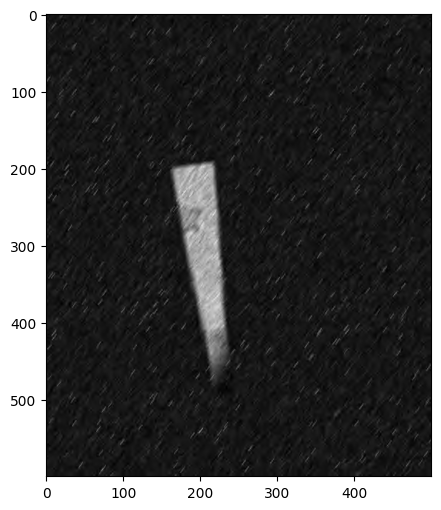

In [8]:
# Debugging
figure, axis = plt.subplots()
figure.set_size_inches(6, 6)
axis.imshow(CTImages[testSlice], cmap=plt.cm.gray)

In [9]:
x = np.arange(0, len(CTImages))
# pk = np.array([imageMoment['m00'] for imageMoment in imagesMoments])
p = np.array([imageMoment[0][0] for imageMoment in imagesMoments])

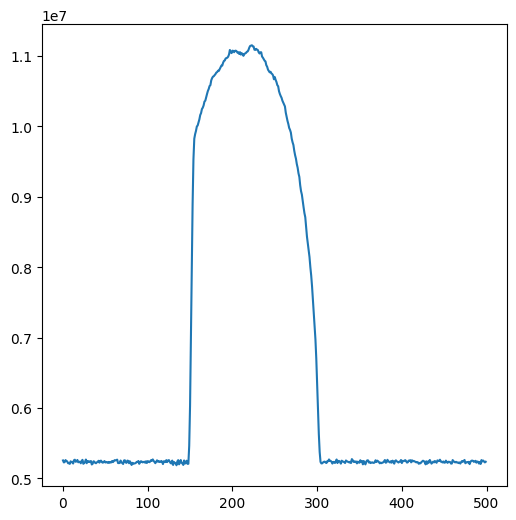

In [10]:
figure, axis = plt.subplots()
figure.set_size_inches(6, 6)
axis.plot(x, p)

In [11]:
# print(pywt.wavelist(kind='discrete'))

In [12]:
# print(pywt.Modes.modes)

In [13]:
p = p - np.min(p)
p = p/np.sum(p)

In [14]:
waveletType='db1'
DWTCoefficients = pywt.wavedec(p, waveletType, mode='periodic', level=4)

In [15]:
threshold = 1e-3
thresholdedDWTCoeffs = [pywt.threshold(coefficient, threshold, mode='soft') for coefficient in DWTCoefficients]

In [16]:
fp = pywt.waverec(thresholdedDWTCoeffs, waveletType, mode='periodic')

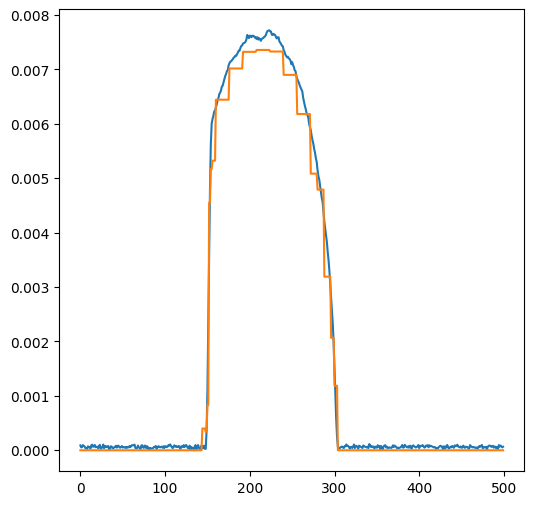

In [17]:
figure, axis = plt.subplots()
figure.set_size_inches(6, 6)
axis.plot(x, p)
axis.plot(x, fp)

In [18]:
fp = fp - np.min(fp)
fp = fp/np.sum(fp)

In [19]:
customDistribution =\
    stats.rv_discrete(
        name='customDistribution',
        values=(x, fp)
    )

In [20]:
stackRange = customDistribution.interval(0.95)

In [21]:
stackRange

(np.float64(156.0), np.float64(292.0))

In [22]:
# offset = (12, 12)

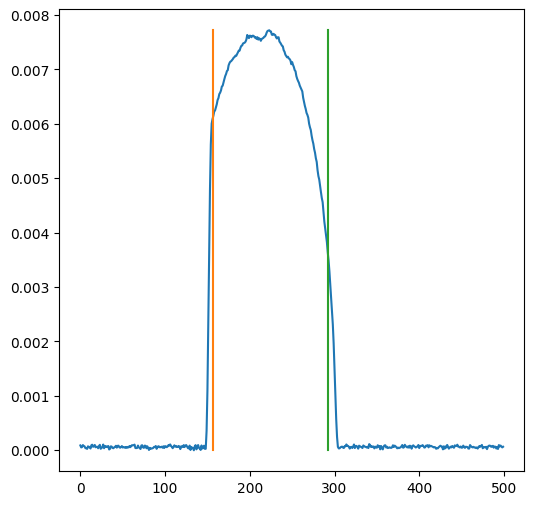

In [23]:
figure, axis = plt.subplots()
figure.set_size_inches(6, 6)
axis.plot(x, p)
axis.plot(
    [stackRange[0], stackRange[0]], [0, np.max(p)],
    [stackRange[1], stackRange[1]], [0, np.max(p)]
)
# axis.plot(
#     [stackRange[0] - offset[0], stackRange[0] - offset[0]], [0, np.max(p)],
#     [stackRange[1] + offset[1], stackRange[1] + offset[1]], [0, np.max(p)]
# )

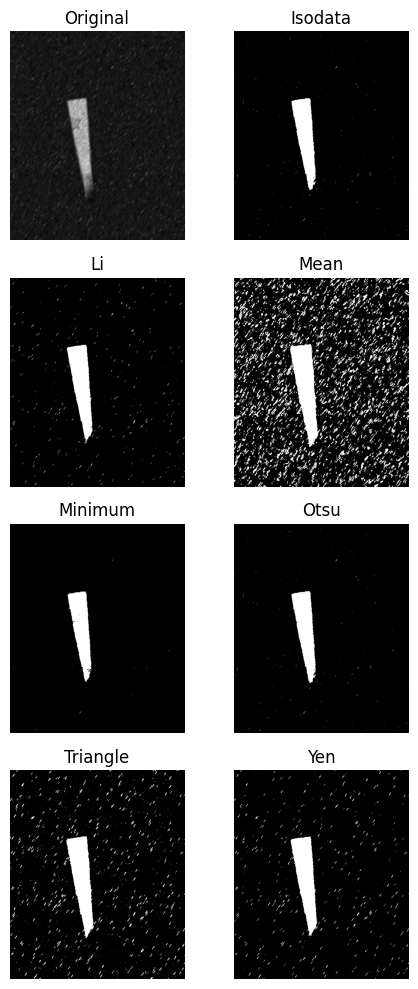

In [24]:
figure, axes = ski.filters.try_all_threshold(CTImages[testSlice], figsize=(5, 10), verbose=False)
plt.show()

In [25]:
entropy = ski.filters.rank.entropy(CTImages[testSlice], ski.morphology.disk(30))

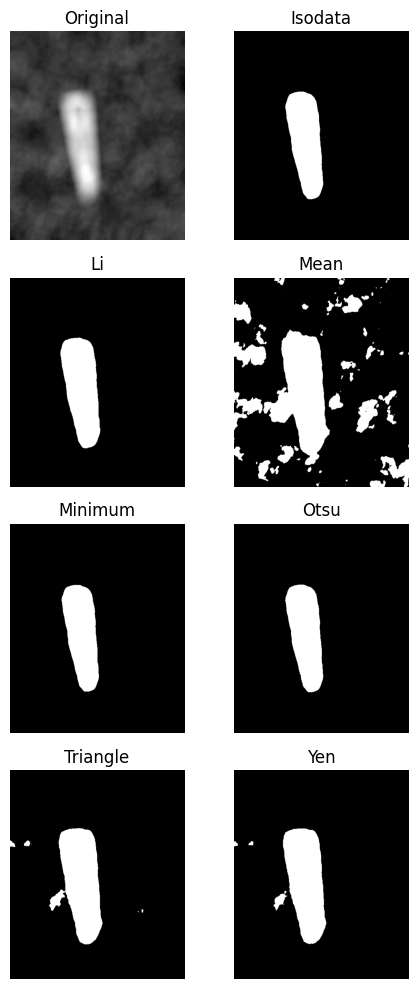

In [26]:
figure, axes = ski.filters.try_all_threshold(entropy, figsize=(5, 10), verbose=False)
plt.show()

In [27]:
# Find contours at a constant value
contours = ski.measure.find_contours(entropy, np.min(entropy) + 0.65*(np.max(entropy) - np.min(entropy)))

In [28]:
binaryImage = entropy > np.min(entropy) + 0.65*(np.max(entropy) - np.min(entropy))

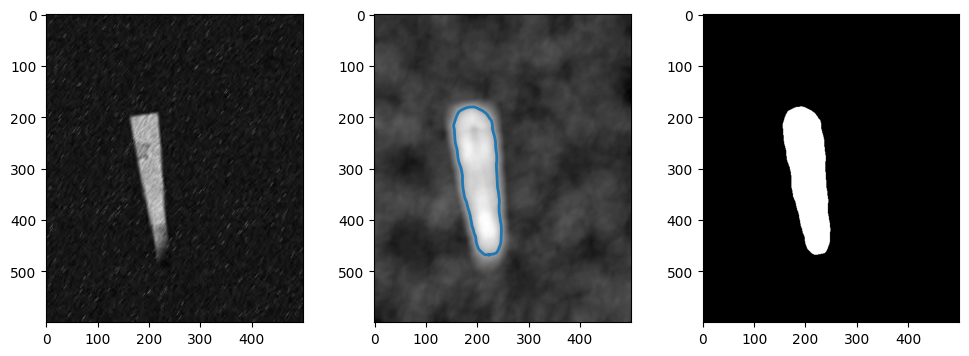

In [29]:
# Debugging
figure, axis = plt.subplots(nrows=1, ncols=3)
figure.set_size_inches(12, 4)
axis[0].imshow(CTImages[testSlice], cmap=plt.cm.gray)
axis[1].imshow(entropy, cmap=plt.cm.gray)
for contour in contours:
    axis[1].plot(contour[:, 1], contour[:, 0], linewidth=2)
axis[2].imshow(binaryImage, cmap=plt.cm.gray)

In [30]:
hull = ski.morphology.convex_hull_image(binaryImage)

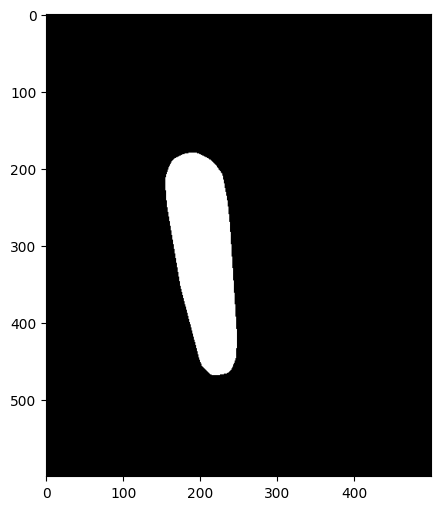

In [31]:
# Debugging
figure, axis = plt.subplots()
figure.set_size_inches(6, 6)
axis.imshow(hull, cmap=plt.cm.gray)

In [32]:
cumulativeHull = np.zeros_like(CTImages[0], dtype=np.uint32)
for CTImage in CTImages[int(stackRange[0]):int(stackRange[1])]:
    entropy = ski.filters.rank.entropy(CTImage, ski.morphology.disk(30))
    binaryImage = entropy > np.min(entropy) + 0.65*(np.max(entropy) - np.min(entropy))
    cumulativeHull += np.uint32(ski.morphology.convex_hull_image(binaryImage))

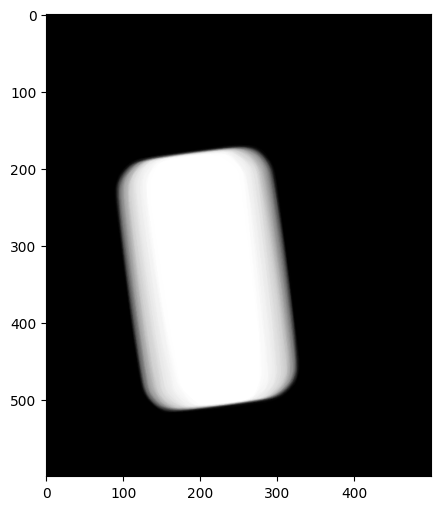

In [33]:
# Debugging
figure, axis = plt.subplots()
figure.set_size_inches(6, 6)
axis.imshow(cumulativeHull, cmap=plt.cm.gray)

In [34]:
binaryImage = cumulativeHull >= np.int32(0.5*(stackRange[1] - stackRange[0]))
labeledImage = ski.measure.label(binaryImage)
regions = ski.measure.regionprops(labeledImage)

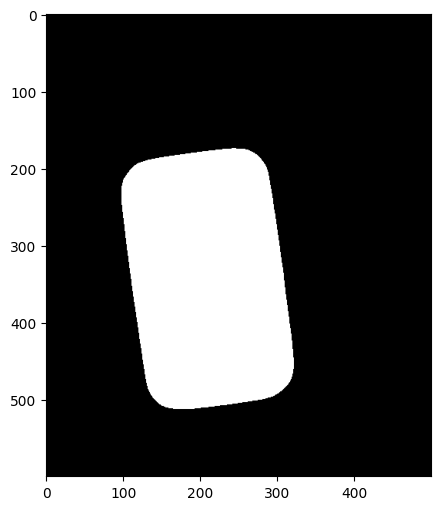

In [35]:
# Debugging
figure, axis = plt.subplots()
figure.set_size_inches(6, 6)
axis.imshow(binaryImage, cmap=plt.cm.gray)

In [36]:
rotated =\
    ski.transform.rotate(
        cumulativeHull,
        angle=-regions[0].orientation*180.0/np.pi,
        center=regions[0].centroid,
        resize=False
    )

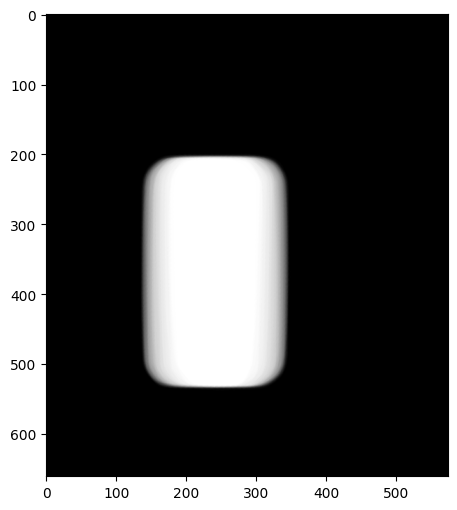

In [37]:
# Debugging
figure, axis = plt.subplots()
figure.set_size_inches(6, 6)
axis.imshow(rotated, cmap=plt.cm.gray)